(convolution)=
# Convolutional predictive coding networks

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ComputationalPsychiatry/pyhgf/blob/master/docs/source/notebooks/0.8-Convolutional_networks.ipynb)


In [ ]:
import sys

from IPython.utils import io

if "google.colab" in sys.modules:
    with io.capture_output() as captured:
        ! pip uninstall -y jax jaxlib
        ! pip install pyhgf watermark jax[cuda12]==0.4.31

In [ ]:
import os
import time
import urllib.request

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import seaborn as sns

from pyhgf.model import (
    DeepNetwork,
    DeepNetworkAdapter,
    FusedPipeline,
    PCSequential,
)
from pyhgf.model.conv import (
    conv_block,
    flatten_adapter,
    im2col_adapter,
    spatial_reshape_adapter,
)
from pyhgf.plots.graphviz.plot_network import plot_deep_network

plt.rcParams["figure.constrained_layout.use"] = True

[Prospective configuration](0.6-Prospective_configuration.ipynb) showed that a `DeepNetwork` learns fully-connected layers with local, precision-weighted updates instead of backpropagation. A convolution is nothing more exotic than a *fully-connected layer shared across every spatial position of an image* — so the same machinery covers it, once the sharing is set up correctly.

This notebook builds that sharing from the ground up, trains it on two synthetic toy tasks, and finishes on real photographs (CIFAR-10). Throughout, we use the **hybrid pipeline** (`pyhgf.model.hybrid`/`pyhgf.model.fused`): a small set of frozen (weightless) *adapters* for the purely geometric parts of a convolution (extracting patches, pooling) wrapped around one small `DeepNetwork` per convolutional layer. Pinning each layer's precision high and freezing its precision updates (the same *backprop-parity recipe* used for the Transformer in earlier notebooks) makes each local update mathematically equal to a backpropagation step, by construction.

## From one shared layer to a convolution

![One shared kernel stepping across every position of the input, writing one value per position into the output feature map.](https://computationalpsychiatry.github.io/pyhgf/_images/convolution.svg)

*The same $k_h \times k_w$ kernel is applied at every position, so the layer holds only $C_{out} \times C_{in} \cdot k_h \cdot k_w$ weights however large the image gets. Drawn with stride 1 and no padding ($H' = H - k_h + 1$); `conv_block` below defaults to `padding="SAME"`, which instead keeps $H' = H$.*

A convolution kernel is a small weight matrix that is *reused* at every position it slides over: the same $3\times 3\times C_{in} \to C_{out}$ linear map, applied independently to every patch of the image. That reuse can be split into three independent pieces:

1. **Extract patches** (`im2col`) — turn every $k_h \times k_w$ neighbourhood of the image into one row of a table. This is a pure reshuffle of the input, with no weights at all.
2. **Apply one shared kernel** — a single small linear map (`out_channels ← in_channels·k_h·k_w`), applied identically to every row/patch. This is the *only* learned part.
3. **Pool** — locally summarise (average or take the max over) small neighbourhoods to shrink the spatial size before the next layer.

`pyhgf.model.conv` implements exactly this split:

- `im2col_adapter` / `avg_pool_adapter` / `max_pool_adapter` / `spatial_reshape_adapter` are **frozen** `EquinoxAdapter`s: closed-form forward and backward passes, no learned parameters.
- `conv_patch_network` builds the one learned piece, a tiny 2-layer `DeepNetwork`, the same object class used for any other fully-connected layer in this library.
- `conv_block` wires all of the above into a single `PCSequential`: `im2col → shared kernel (as a DeepNetworkAdapter) → GELU → reshape → pool`.

Before trusting that wiring, let's check it against a real convolution directly.

In [ ]:
# A small synthetic image with a sharp vertical edge (bright on the right half).
size = 12
image = np.zeros((1, 1, size, size), dtype="float32")
image[0, 0, :, size // 2 :] = 1.0
image += np.random.default_rng(0).normal(scale=0.05, size=image.shape).astype("float32")

# A hand-set vertical-edge (Sobel-x) kernel -- no training involved yet.
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype="float32")
kernel = sobel_x[None, None, :, :]  # (out_channels=1, in_channels=1, kh=3, kw=3)

# Patch-extract by hand, then apply the shared kernel as one matrix product --
# this *is* what conv_block's im2col_adapter + DeepNetworkAdapter do internally.
patcher = im2col_adapter(filter_shape=(3, 3), strides=(1, 1), padding="SAME")
patches, _ = patcher.forward_fn(jnp.asarray(image))  # (1, n_patches, 9)
by_hand = patches @ kernel.reshape(1, -1).T  # (1, n_patches, out_channels)
by_hand = spatial_reshape_adapter(size, size).forward_fn(by_hand)[0]

# Ground truth: jax.lax's real convolution.
reference = jax.lax.conv_general_dilated(
    jnp.asarray(image),
    jnp.asarray(kernel),
    window_strides=(1, 1),
    padding="SAME",
    dimension_numbers=("NCHW", "OIHW", "NCHW"),
)

print(
    "max abs difference vs. jax.lax.conv_general_dilated:",
    float(jnp.max(jnp.abs(by_hand - reference))),
)

fig, axs = plt.subplots(1, 2, figsize=(7, 3.2))
axs[0].imshow(image[0, 0], cmap="gray")
axs[0].set_title("Input image")
axs[1].imshow(np.asarray(by_hand)[0, 0], cmap="RdBu_r")
axs[1].set_title("Patches @ kernel (= real convolution)")
for ax in axs:
    ax.axis("off")

`im2col_adapter`'s patch table, multiplied by the flattened kernel, reproduces `jax.lax.conv_general_dilated` to floating-point precision — the two panels above show the same computation, one done "by hand" and one by JAX's own convolution primitive. `conv_block` replaces the hand-written matrix product with a `DeepNetworkAdapter` wrapping a trainable `conv_patch_network` (plus a GELU activation and a pooling step), so the kernel above becomes *learned* rather than hand-set — everything else about the wiring stays identical.

conv_block parts: ['EquinoxAdapter', 'DeepNetworkAdapter', 'EquinoxAdapter', 'EquinoxAdapter', 'EquinoxAdapter']
output shape (channels, height, width): (4, 6, 6)


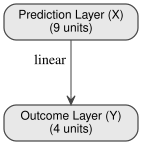

In [ ]:
part, out_shape = conv_block(
    in_channels=1,
    out_channels=4,
    in_height=size,
    in_width=size,
    filter_shape=(3, 3),
    padding="SAME",
    pool_kind="max",
    key=jax.random.key(0),
)
print("conv_block parts:", [type(p).__name__ for p in part.parts])
print("output shape (channels, height, width):", out_shape)

# The one learned piece is a plain DeepNetwork -- the same class used for any
# fully-connected layer in this library.
kernel_net = part.parts[1].net
plot_deep_network(kernel_net, view=False)

Two layers: the top one holds the flattened patch (`in_channels·k_h·k_w` nodes), the bottom one the output feature map (`out_channels` nodes), and small enough that training it costs about as much as training any other 2-layer `DeepNetwork`, no matter how large the image it gets applied to.

## A reusable training recipe

Every example below follows the same shape: stack one or more `conv_block`s, flatten the final feature map, and finish with a small `DeepNetwork` classifier whose bottom layer is `kind="categorical"` (a softmax over the class logits for which the prediction error is exactly the cross-entropy gradient).

```{hint}
`PARITY`/`PARITY_LEAF` are the backprop-parity settings we use to recover the backpropagaion gradient: high, effectively-fixed precision and no volatility parent.
```

In [ ]:
PARITY = dict(volatility_parent=False, precision=1e4, expected_precision=1e4)
PARITY_LEAF = dict(volatility_parent=False)


def build_conv_classifier(
    conv_channels,
    in_channels,
    in_hw,
    n_classes,
    hidden=32,
    lr=1e-3,
    pool_kind="max",
    key=None,
):
    """Build one conv_block per entry in ``conv_channels``, then a classifier.

    Returns the fused pipeline and the ``(channels, height, width)`` of the
    feature map reaching the classifier.
    """
    key = jax.random.key(0) if key is None else key
    keys = list(jax.random.split(key, len(conv_channels) + 1))

    parts, c, h, w = [], in_channels, in_hw, in_hw
    for out_c, k in zip(conv_channels, keys[:-1]):
        block, (c, h, w) = conv_block(
            c,
            out_c,
            h,
            w,
            filter_shape=(3, 3),
            padding="SAME",
            pool_kind=pool_kind,
            optimiser=optax.adam(lr),
            key=k,
            leaf_kwargs=PARITY_LEAF,
            layer_kwargs=PARITY,
        )
        parts.append(block)

    classifier_net = (
        DeepNetwork()
        .add_layer(
            size=n_classes, kind="categorical", add_constant_input=False, **PARITY_LEAF
        )
        .add_layer(
            size=hidden, add_constant_input=False, coupling_fn=jax.nn.gelu, **PARITY
        )
        .add_layer(size=c * h * w, add_constant_input=False, **PARITY)
    ).weight_initialisation("he", key=keys[-1])
    classifier = DeepNetworkAdapter(
        classifier_net,
        optimiser=optax.adam(lr),
        learning_kind="precision_weighted",
    )
    parts += [flatten_adapter(c, h, w), classifier]

    fused = FusedPipeline(
        PCSequential(parts),
        error_fn=lambda probs, ids: probs - jax.nn.one_hot(ids, n_classes),
    )
    return fused, (c, h, w)


def split(images, labels, train_fraction=0.8):
    """Cut a dataset into a training and a test part.

    Returns them in the same ``(train, test)`` order as ``load_cifar10`` below.
    """
    n = int(train_fraction * len(images))
    return images[:n], labels[:n], images[n:], labels[n:]


def show_examples(images, labels, class_names):
    """Draw the first six images of a dataset above their class names.

    One channel is drawn grey, three as RGB.
    """
    _, axs = plt.subplots(1, 6, figsize=(10, 2))
    for ax, image, label in zip(axs, images, labels):
        if image.shape[0] == 1:
            ax.imshow(image[0], cmap="gray")
        else:
            ax.imshow(np.clip(image.transpose(1, 2, 0), 0, 1))
        ax.set_title(class_names[label], fontsize=9)
        ax.axis("off")


def evaluate(fused, images, labels, batch=500):
    """Return the accuracy over a dataset, predicting it in batches."""
    hits = [
        np.asarray(fused.predict(jnp.asarray(images[s : s + batch]))).argmax(-1)
        == labels[s : s + batch]
        for s in range(0, len(images), batch)
    ]
    return float(np.mean(np.concatenate(hits)))


def train_classifier(
    fused, X_tr, y_tr, X_te, y_te, epochs, batch_size, seed=0, log_every=1
):
    """Train for ``epochs`` passes, reporting loss and accuracy after each.

    Accuracy on the training rows is collected from the same forward pass that
    drives learning; accuracy on the test rows is measured separately after
    every epoch.
    """
    rng = np.random.default_rng(seed)
    history = {"train_loss": [], "train_acc": [], "test_acc": []}
    for epoch in range(epochs):
        order = rng.permutation(len(X_tr))
        losses, accuracies = [], []
        # Every batch is full-size, so the epoch means below are unweighted.
        for start in range(0, len(order) - batch_size + 1, batch_size):
            batch = order[start : start + batch_size]
            labels = y_tr[batch]
            probs, _ = fused.step(jnp.asarray(X_tr[batch]), jnp.asarray(labels))
            probs = np.asarray(probs)
            p_true = probs[np.arange(len(labels)), labels]
            losses.append(-np.mean(np.log(np.clip(p_true, 1e-7, 1.0))))
            accuracies.append(np.mean(probs.argmax(-1) == labels))
        history["train_loss"].append(float(np.mean(losses)))
        history["train_acc"].append(float(np.mean(accuracies)))
        history["test_acc"].append(evaluate(fused, X_te, y_te))
        if epoch % log_every == 0 or epoch == epochs - 1:
            print(
                f"epoch {epoch:3d} | train loss {history['train_loss'][-1]:.3f} "
                f"acc {history['train_acc'][-1]:.3f} | "
                f"test acc {history['test_acc'][-1]:.3f}"
            )
    return history


def plot_history(history, title):
    """Plot the training loss, and the training and test accuracy, per epoch."""
    deep = sns.color_palette("deep")
    _, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Only the training rows have a loss recorded, so this panel carries one line.
    axs[0].plot(history["train_loss"], alpha=0.8, color=deep[0])
    axs[0].set(xlabel="Epoch", ylabel="Cross-entropy", title=f"{title} — Loss")
    axs[0].grid(linestyle="--")

    axs[1].plot(history["train_acc"], label="Train", alpha=0.8, color=deep[0])
    axs[1].plot(history["test_acc"], label="Test", alpha=0.8, color=deep[3])
    axs[1].set(xlabel="Epoch", ylabel="Accuracy", title=f"{title} — Accuracy")
    axs[1].legend()
    axs[1].grid(linestyle="--")

    sns.despine()

## Toy example 1: horizontal vs. vertical stripes

The simplest possible spatial-pattern task: single-channel $16\times 16$ images containing either horizontal or vertical stripes, buried in noise. One `conv_block` (1 input channel → 4 feature maps) followed by the classifier above is enough.

In [ ]:
def make_stripes(n_samples=600, size=16, period=4, noise=0.35, seed=0):
    """Draw noisy images of horizontal (label 0) or vertical (label 1) stripes."""
    rng = np.random.default_rng(seed)
    labels = rng.integers(0, 2, size=n_samples)  # 0 = horizontal, 1 = vertical
    bars = (np.sin(2 * np.pi * np.arange(size) / period) > 0).astype("float32")
    horizontal = np.broadcast_to(bars[:, None], (size, size))
    vertical = np.broadcast_to(bars[None, :], (size, size))
    images = np.where(labels[:, None, None, None] == 0, horizontal, vertical)
    images = images + rng.normal(scale=noise, size=images.shape)
    return images.astype("float32"), labels.astype("int64")


X_stripes, y_stripes = make_stripes()
X_tr_s, y_tr_s, X_te_s, y_te_s = split(X_stripes, y_stripes)

show_examples(X_stripes, y_stripes, ["horizontal", "vertical"])
print(f"train: {len(X_tr_s)}  test: {len(X_te_s)}")

In [ ]:
fused_stripes, feature_map = build_conv_classifier(
    conv_channels=[4],
    in_channels=1,
    in_hw=16,
    n_classes=2,
    hidden=16,
    key=jax.random.key(1),
)
print("feature map before the classifier:", feature_map)

history_stripes = train_classifier(
    fused_stripes,
    X_tr_s,
    y_tr_s,
    X_te_s,
    y_te_s,
    epochs=8,
    batch_size=32,
    log_every=2,
)
plot_history(history_stripes, "Stripes")

## Toy example 2: circles, squares, and crosses

A step up: three-way classification, three-channel $20\times 20$ images, and **two** stacked `conv_block`s (with pooling shrinking the spatial size in between) — the same pattern real conv nets use to build up from local edges to whole-object detectors.

In [ ]:
def make_shapes(n_samples=900, size=20, noise=0.3, seed=0):
    """Draw noisy three-channel images of a circle, a square or a cross."""
    rng = np.random.default_rng(seed)
    labels = rng.integers(0, 3, size=n_samples)  # 0 circle, 1 square, 2 cross
    yy, xx = np.meshgrid(np.arange(size), np.arange(size), indexing="ij")
    # Each shape sits at the centre, jittered a couple of pixels per sample.
    cy, cx = size / 2 + rng.uniform(-2.0, 2.0, (2, n_samples, 1, 1))
    radius, thickness = size * 0.3, size * 0.15
    circle = (yy - cy) ** 2 + (xx - cx) ** 2 <= radius**2
    square = (np.abs(yy - cy) <= radius * 0.8) & (np.abs(xx - cx) <= radius * 0.8)
    cross = (np.abs(yy - cy) <= thickness) | (np.abs(xx - cx) <= thickness)
    shape = labels[:, None, None]
    masks = np.select([shape == 0, shape == 1], [circle, square], default=cross)
    # The same mask in all three channels; the noise below differs between them.
    images = np.broadcast_to(
        masks[:, None].astype("float32"), (n_samples, 3, size, size)
    )
    images = images + rng.normal(scale=noise, size=images.shape)
    return images.astype("float32"), labels.astype("int64")


X_shapes, y_shapes = make_shapes()
X_tr_sh, y_tr_sh, X_te_sh, y_te_sh = split(X_shapes, y_shapes)

show_examples(X_shapes, y_shapes, ["circle", "square", "cross"])
print(f"train: {len(X_tr_sh)}  test: {len(X_te_sh)}")

In [ ]:
fused_shapes, feature_map = build_conv_classifier(
    conv_channels=[8, 16],
    in_channels=3,
    in_hw=20,
    n_classes=3,
    hidden=32,
    key=jax.random.key(2),
)
print("feature map before the classifier:", feature_map)

history_shapes = train_classifier(
    fused_shapes,
    X_tr_sh,
    y_tr_sh,
    X_te_sh,
    y_te_sh,
    epochs=12,
    batch_size=32,
    log_every=3,
)
plot_history(history_shapes, "Shapes")

## CIFAR-10: real photographs

Finally, the same recipe on real, natural images: CIFAR-10, $32\times 32$ RGB photographs of ten everyday subjects. We fetch a small excerpt of the collection (3,000 training and 1,000 test photographs, cached under `data/`) rather than the full 170 MB archive, and train on it for a handful of epochs. The network is made of two convolutional blocks, uses max-pooling and a GELU-coupled classifier.

In [ ]:
CIFAR10_URL = (
    "https://raw.githubusercontent.com/ilabcode/hgf-data/main/datasets/"
    "cifar10_subset.npz"
)
CIFAR10_FILE = os.path.join("..", "..", "..", "data", "cifar10_subset.npz")
# Colour channel means and standard deviations of the full CIFAR-10 training set.
CIFAR10_MEAN = np.array([0.4914, 0.4822, 0.4465], dtype="float32")
CIFAR10_STD = np.array([0.2023, 0.1994, 0.2010], dtype="float32")


def _normalise(images):
    """Scale bytes to the unit interval, then centre each colour channel."""
    images = images.astype("float32") / 255.0
    images -= CIFAR10_MEAN[None, :, None, None]
    images /= CIFAR10_STD[None, :, None, None]
    return images


def load_cifar10(path, n_train=2000, n_test=1000):
    """Return a normalised CIFAR-10 excerpt, downloading it on first use.

    The file holds 3,000 training and 1,000 test photographs stored as unsigned
    bytes, 300 and 100 of each of the ten classes. Its rows keep the shuffled
    order of the source collection, so the leading ``n_train`` of them stay
    close to evenly spread across the classes.
    """
    if not os.path.exists(path):
        # Download to a partial name first, so an interrupted run is not cached.
        print(f"Downloading {CIFAR10_URL} ...")
        os.makedirs(os.path.dirname(path), exist_ok=True)
        urllib.request.urlretrieve(CIFAR10_URL, path + ".part")
        os.replace(path + ".part", path)

    with np.load(path) as data:
        train_images, train_labels = data["train_images"], data["train_labels"]
        test_images, test_labels = data["test_images"], data["test_labels"]
        class_names = [str(name) for name in data["class_names"]]

    if n_train > len(train_images) or n_test > len(test_images):
        raise ValueError(
            f"the file holds {len(train_images)} training and {len(test_images)} "
            f"test images, too few for n_train={n_train}, n_test={n_test}."
        )

    return (
        _normalise(train_images[:n_train]),
        train_labels[:n_train],
        _normalise(test_images[:n_test]),
        test_labels[:n_test],
        class_names,
    )


X_tr_c, y_tr_c, X_te_c, y_te_c, CLASS_NAMES = load_cifar10(CIFAR10_FILE)

# Undo the normalisation for display only; the network trains on normalised images.
shown = X_tr_c * CIFAR10_STD[:, None, None] + CIFAR10_MEAN[:, None, None]
show_examples(shown, y_tr_c, CLASS_NAMES)
print(f"train: {len(X_tr_c)}  test: {len(X_te_c)}")

In [ ]:
fused_cifar, feature_map = build_conv_classifier(
    conv_channels=[16, 32],
    in_channels=3,
    in_hw=32,
    n_classes=10,
    hidden=64,
    key=jax.random.key(3),
)
print("feature map before the classifier:", feature_map)

t0 = time.time()
history_cifar = train_classifier(
    fused_cifar,
    X_tr_c,
    y_tr_c,
    X_te_c,
    y_te_c,
    epochs=20,
    batch_size=64,
    log_every=4,
)
print(f"total training time: {time.time() - t0:.1f}s")
plot_history(history_cifar, "CIFAR-10")

Even this reduced-scale run climbs well above the 10% chance level, using nothing but the local, precision-weighted belief updates from earlier notebooks.

```{note}
What the run does *not* show is generalisation. In the right-hand panel above the training and test curves separate partway through, and the run ends with training accuracy far ahead of test accuracy: the network is fitting the 2,000 images it was shown rather than learning to classify photographs in general. That gap is what a subset this small buys, and it is the expected behaviour of any conv net of this size trained on so few images.
```

The building blocks used here (`im2col_adapter`, `conv_block`, `from_conv` for transplanting externally-trained kernels) scale directly to deeper, wider architectures and the full training set, at a proportional compute cost.

# System configuration

In [ ]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pyhgf,jax,jaxlib

Last updated: Tue, 04 Aug 2026

Python implementation: CPython
Python version       : 3.12.3
IPython version      : 9.13.0

pyhgf : 0.3.0
jax   : 0.11.0
jaxlib: 0.11.0

IPython   : 9.13.0
jax       : 0.11.0
matplotlib: 3.10.9
numpy     : 2.5.1
optax     : 0.2.8
pyhgf     : 0.3.0
seaborn   : 0.13.2

Watermark: 2.6.0

